In [24]:
from scipy.stats import ks_2samp
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
import numpy as np
import matplotlib.pyplot as plt

Data su dva skupa podataka, jedan sa m mjerenja, i drugi sa n mjerenja. Prvi skup se
odnosi na gustine fluksa mjerene u slucajnim pozicijama na nebu, a drugi na gustine fluksa
mjerene u pozicijama specificnih grupa galaksija (gustina fluksa je S [mJy]).

ZADATAK 1. Podaci su dati u obliku histograma. Rekonstruisati sirove uzorke i objasniti zasto je ovaj korak neophodan (moze se koristiti npr. np.repeat). Iscrtati pripadajuce histograme.

In [15]:
ks_uzorci = np.genfromtxt("gr.dat", skip_header=2, skip_footer=2)    # ucitavanje podataka iz gr.dat

mJy, G, R = ks_uzorci.T                            # kolona Mjy - vrednosti fluksa

G_raw = np.repeat(mJy, G.astype(int))              # kolona G: koliko puta se odredjeni fluks pojavljuje na specificnim pozicijama
R_raw = np.repeat(mJy, R.astype(int))              # kolona R: koliko puta se odredjeni fluks pojavljuje na random lokacijama

print(G_raw.size, R_raw.size)

386 290


Podaci su dati u obliku histograma, tj. kao broj pojavljivanja svake vrednosti fluksa. Posto Kolmogorov–Smirnov test zahteva individualna merenja, histogramske frekvencije su rekonstruisane u sirove uzorke koriscenjem funkcije np.repeat, koja svaku vrednost fluksa ponavlja onoliko puta koliko je navedeno u histogramu. Nakon rekonstrukcije dobijena su dva uzorka veličina m=386 i n=290.

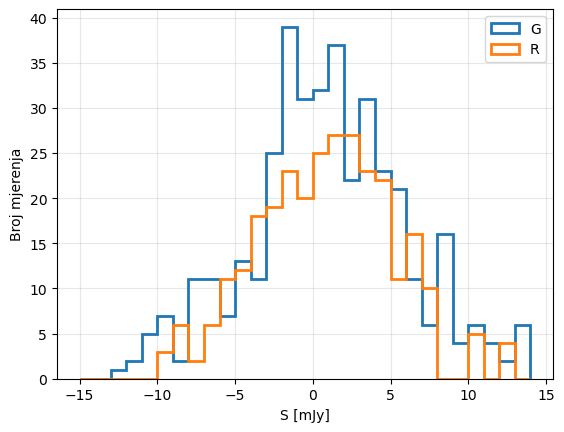

In [29]:
bins = np.arange(min(mJy), max(mJy), 1)      # binovi centrirani na celobrojnim vrednostima

plt.figure()

plt.hist(G_raw, bins=bins, histtype='step', linewidth=2, label='G')
plt.hist(R_raw, bins=bins, histtype='step', linewidth=2, label='R')

plt.xlabel('S [mJy]')
plt.ylabel('Broj mjerenja')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

ZADATAK 2. Koristeci se Kolmogorov-Smirnov dvouzorackim testom, treba ispitati hipotezu da postoji eksces gustine fluksa na ne-slucajnim pozicijama. Dodatno provjeriti hipotezu koristeci se U-testom. Interpretirati.

$H_0$ - Gustine fluksa na grupama galaksija i slučajnim pozicijama imaju istu raspodelu<br>
$H_1$ - Grupe galaksija imaju veće gustine fluksa (eksces)

In [22]:
ks = ks_2samp(G_raw, R_raw, alternative='less')       # Kolmogorov-Smirnov dvouzoracki test
print(ks)

u_test = mannwhitneyu(G_raw, R_raw, alternative='greater')    # u-test 
print(u_test)

KstestResult(statistic=0.06741111309630159, pvalue=0.20990505201364296, statistic_location=7.0, statistic_sign=-1)
MannwhitneyuResult(statistic=56613.5, pvalue=0.3988043118334691)


Kako je u oba testa p>0.05, nema dovoljno dokaza za eksces.

ZADATAK 3. Generisati dva skupa od po n = 10 posmatranja: jedan iz raspodjele N (0, 1), drugi
iz mjesavine (1 − ε)N (0, 1) + εN (0, 3), i primijeniti t-test na njih, provjeravajuci da li se H0 : μ1 = μ2 odbacuje na nivou znacajnosti α = 0.05.<br>
Ovaj postupak (generisanje + t-test) ponoviti 1000 puta za svaku od 20 vrijednosti ε ∈ [0, 0.5], i izracunati udio slucajeva u kojima se $H_0$ odbacuje za svako ε. Prikazati zavisnost ovog udjela od ε.<br>

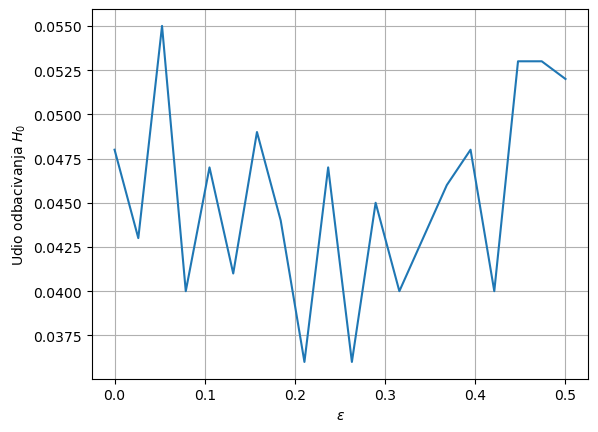

In [37]:
n = 10                  # br posmatranja u svakom od dva skupa
Nsim = 1000             # broj ponavljanja postupka
alpha = 0.05            # nivo znacajnosti

eps_values = np.linspace(0,0.5,20)     # ε ∈ [0, 0.5]

reject_fraction = []                   # koliko ima odbacenih ?

for eps in eps_values:                 # za svako ε 

    reject = 0                         # inicijalizacija promenljive koju updatujemo i dodajemo u niz 

    for i in range(Nsim):              # za svako ε ponavljamo postupak N puta

        x = np.random.normal(0,1,n)    # prvi uzorak - N(0, 1)  μ=0, σ=1
        choice = np.random.rand(n)     
        y = np.where(choice < eps, np.random.normal(0,3,n), np.random.normal(0,1,n))       # drugi uzorak - mešavina N(0, 1) i N(0, 3)

        t, p = ttest_ind(x,y)          # t-test
        if p < alpha:
            reject += 1

    reject_fraction.append(reject/Nsim)


plt.figure()

plt.plot(eps_values, reject_fraction, '-')

plt.xlabel(r'$\epsilon$')
plt.ylabel('Udio odbacivanja $H_0$')
plt.grid()

plt.show()

Zatim ponoviti citav postupak promjenom srednje vrijednosti uze normalne raspodjele na μ = 0.5.

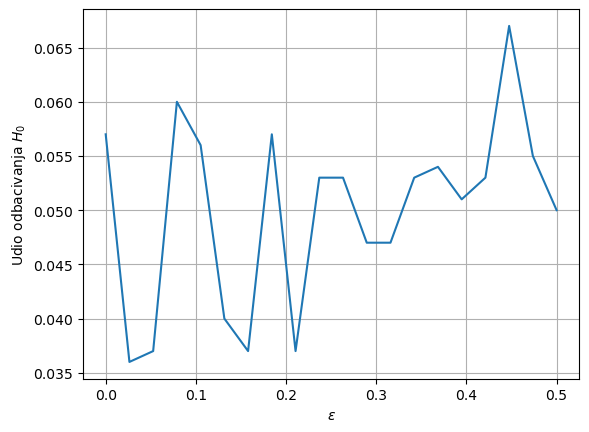

In [43]:
reject_fraction = []                   # koliko ima odbacenih ?

for eps in eps_values:                 # za svako ε 

    reject = 0                         # inicijalizacija promenljive koju updatujemo i dodajemo u niz 

    for i in range(Nsim):              # za svako ε ponavljamo postupak N puta

        x = np.random.normal(0.5,1,n)  # prvi uzorak - N(0.5, 1)  μ=0.5, σ=1
        choice = np.random.rand(n)     
        y = np.where(choice < eps, np.random.normal(0,3,n), np.random.normal(0.5,1,n))    # drugi uzorak - mešavina N(0.5, 1) i N(0, 3)

        t, p = ttest_ind(x,y)          # t-test
        if p < alpha:
            reject += 1

    reject_fraction.append(reject/Nsim)


plt.figure()

plt.plot(eps_values, reject_fraction, '-')

plt.xlabel(r'$\epsilon$')
plt.ylabel('Udio odbacivanja $H_0$')
plt.grid()

plt.show()